In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path = r"..\data\gold\olist_"
gold_orders = pd.read_parquet(file_path+"orders.parquet")
gold_customers = pd.read_parquet(file_path+"customers.parquet")
gold_products = pd.read_parquet(file_path + "products.parquet")

In [6]:
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# 01 - Business Overview

## Objectif

Ce notebook présente une vue d'ensemble de l'activité e-commerce à partir des tables Gold.

Les objectifs sont de mesurer :
- le volume d'activité ;
- le chiffre d'affaires ;
- le panier moyen ;
- le nombre de clients ;
- le volume d'articles vendus ;
- l'évolution temporelle de l'activité ;
- les principaux indicateurs de fidélisation.

In [ ]:
start_date = gold_orders["order_purchase_timestamp"].min()
end_date = gold_orders["order_purchase_timestamp"].max()
analysis_days = (end_date - start_date).days
print(f"Période couverte : {analysis_days} jours")
print(f"Début : {start_date}")
print(f"Fin   : {end_date}")

Période couverte : 772 jours
Début : 2016-09-04 21:15:19
Fin   : 2018-10-17 17:30:18


In [90]:
monthly_coverage = gold_orders.groupby(
    gold_orders["order_purchase_timestamp"].dt.to_period("M")
).agg(
    first_date=("order_purchase_timestamp", "min"),
    last_date=("order_purchase_timestamp", "max"),
    nb_orders=("order_id", "nunique"),
)

monthly_coverage["days_covered"] = (
    monthly_coverage["last_date"] - monthly_coverage["first_date"]
).dt.days + 1

monthly_coverage


,first_date,last_date,nb_orders,days_covered
order_purchase_timestamp,,,,
2016-09,2016-09-04 21:15:19,2016-09-15 12:16:38,4,11
2016-10,2016-10-02 22:07:52,2016-10-22 08:25:27,324,20
2016-12,2016-12-23 23:16:47,2016-12-23 23:16:47,1,1
2017-01,2017-01-05 11:56:06,2017-01-31 23:37:58,800,27
2017-02,2017-02-01 00:04:17,2017-02-28 23:47:08,1780,28
2017-03,2017-03-01 00:01:30,2017-03-31 23:54:45,2682,31
2017-04,2017-04-01 00:54:10,2017-04-30 23:48:13,2404,30
2017-05,2017-05-01 01:18:22,2017-05-31 22:59:52,3700,31
2017-06,2017-06-01 00:05:38,2017-06-30 23:20:08,3245,30


In [93]:
analysis_orders = gold_orders.loc[
    gold_orders["order_purchase_timestamp"].between("2017-02-01", "2018-08-31 23:59:59")
].copy()


In [15]:
total_orders = gold_orders["order_id"].nunique()

total_customers = gold_orders["customer_unique_id"].nunique()

total_revenue = gold_orders["order_value"].sum()

avg_order_value = gold_orders["order_value"].mean()

total_items = gold_orders["nb_items"].sum()

avg_items_per_order = gold_orders["nb_items"].mean()

total_freight = gold_orders["freight_value"].sum()

product_revenue = gold_orders["products_value"].sum()
gross_order_value = gold_orders["order_value"].sum()
freight_revenue = gold_orders["freight_value"].sum()


In [16]:
kpis = pd.Series(
    {
        "Total Orders": total_orders,
        "Unique Customers": total_customers,
        "Total Revenue": total_revenue,
        "Average Order Value": avg_order_value,
        "Total Items Sold": total_items,
        "Average Items / Order": avg_items_per_order,
        "Total Freight": total_freight,
        "Product Revenue": product_revenue,
        "Freight Revenue": freight_revenue,
        "Gross Order Value": gross_order_value,
    }
)

kpis


Total Orders                99,441.00
Unique Customers            96,096.00
Total Revenue           15,843,553.24
Average Order Value            160.58
Total Items Sold           112,650.00
Average Items / Order            1.14
Total Freight            2,251,909.54
Product Revenue         13,591,643.70
Freight Revenue          2,251,909.54
Gross Order Value       15,843,553.24
dtype: float64

In [94]:
order_status = (
    gold_orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="nb_orders")
)

order_status["percentage"] = (
    order_status["nb_orders"] / order_status["nb_orders"].sum() * 100
)

order_status


,order_status,nb_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [25]:
gold_orders["purchase_month_date"] = (
    gold_orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
)


In [109]:
analysis_orders["purchase_month_date"] = (
    analysis_orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
)


In [111]:
monthly_business = analysis_orders.groupby(
    analysis_orders["purchase_month_date"].dt.to_period("M").dt.to_timestamp(),
    as_index=False,
).agg(
    nb_orders=("order_id", "nunique"),
    nb_customers=("customer_unique_id", "nunique"),
    gross_order_value=("order_value", "sum"),
)


In [112]:
monthly_business["avg_order_value"] = (
    monthly_business["gross_order_value"] / monthly_business["nb_orders"]
)


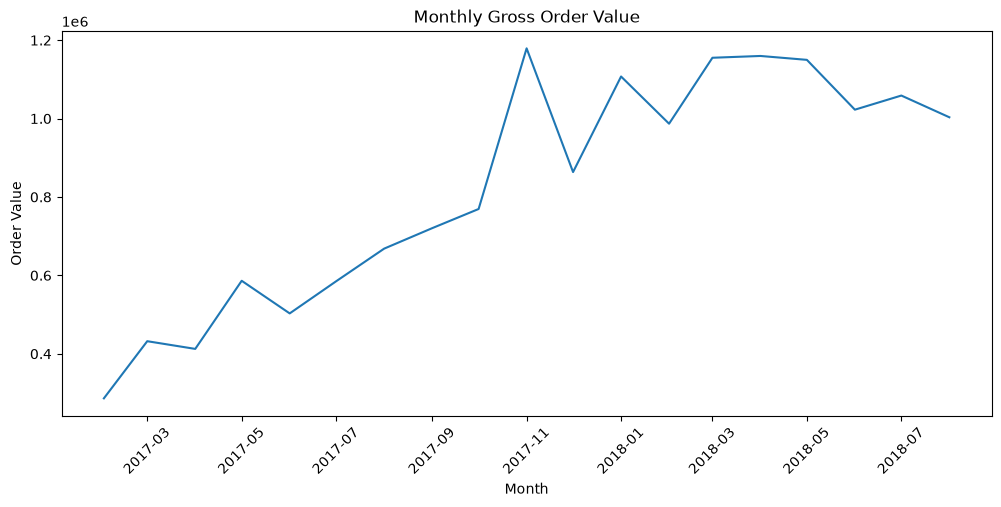

In [113]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_business["purchase_month_date"], monthly_business["gross_order_value"])

plt.title("Monthly Gross Order Value")
plt.xlabel("Month")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()

La couverture temporelle du dataset est irrégulière aux extrémités de la période. Les mois de 2016 ainsi que septembre et octobre 2018 présentent un nombre de commandes trop faible pour être comparés aux mois complets. L’analyse des tendances mensuelles est donc restreinte à février 2017 – août 2018 afin d’éviter des conclusions biaisées par une couverture partielle des données. Sur cette période, l’activité connaît une forte progression en 2017, suivie d’un niveau élevé et relativement stable en 2018. Un pic particulièrement marqué est observé en novembre 2017 et mérite une analyse spécifique de la saisonnalité.

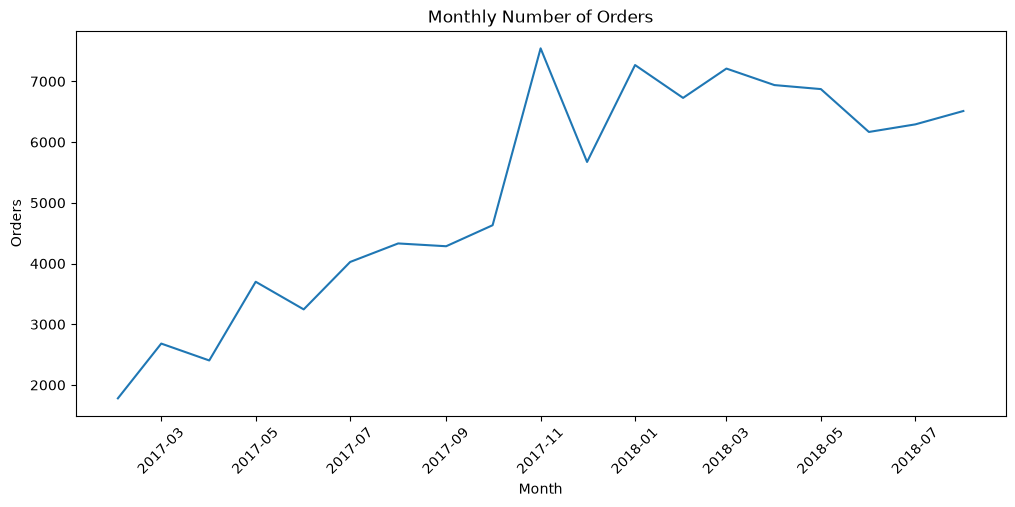

In [114]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_business["purchase_month_date"], monthly_business["nb_orders"])

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()


Le nombre mensuel de commandes augmente fortement au cours de l’année 2017, passant d’environ 1 800 commandes en février à plus de 7 500 en novembre. Le pic de novembre 2017 se distingue nettement du reste de la série et suggère un effet saisonnier ou promotionnel important. Après une baisse en décembre, le volume repart à un niveau élevé début 2018, autour de 6 500 à 7 300 commandes par mois. À partir du printemps 2018, l’activité semble se stabiliser, avec une légère baisse en juin suivie d’une reprise progressive jusqu’en août.

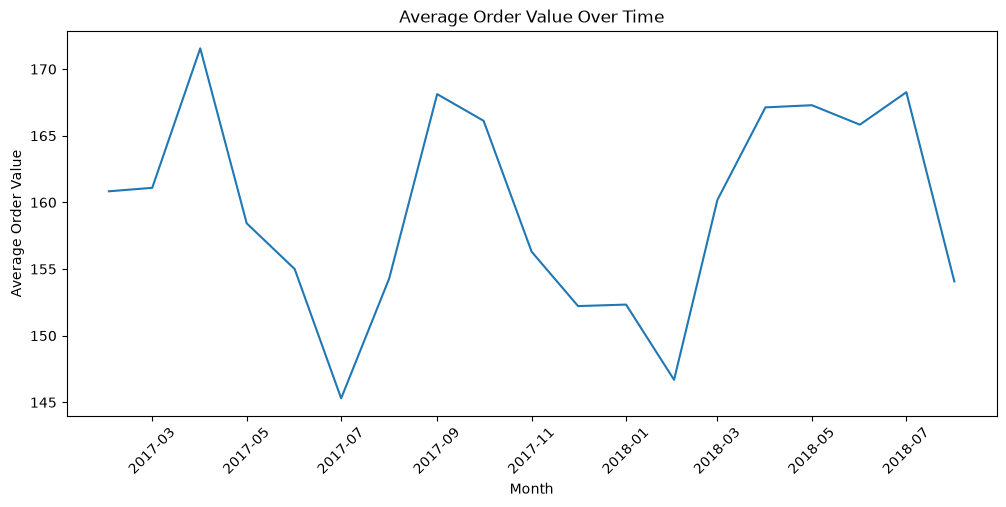

In [115]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_business["purchase_month_date"], monthly_business["avg_order_value"])

plt.title("Average Order Value Over Time")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.show()


Le panier moyen mensuel reste relativement stable sur la période étudiée, oscillant principalement entre 145 et 170. Certaines variations ponctuelles sont observées, notamment un niveau élevé au printemps 2017 et une baisse autour de juin-juillet 2017 et février 2018, mais aucune tendance haussière durable ne se dégage. Cette stabilité contraste avec la forte augmentation du nombre de commandes observée en 2017. La croissance de la valeur brute des commandes semble donc être principalement portée par l’augmentation du volume de commandes plutôt que par une hausse du montant moyen dépensé par commande.

In [31]:
customer_type = (
    gold_customers["is_repeat_customer"]
    .value_counts()
    .rename({False: "One-time customer", True: "Repeat customer"})
)

customer_type


is_repeat_customer
One-time customer    93099
Repeat customer       2997
Name: count, dtype: int64

In [ ]:
repeat_customer_rate = gold_customers["is_repeat_customer"].mean() * 100

print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")


Repeat customer rate: 3.12%


In [34]:
gold_customers["nb_orders"].describe()


count   96,096.00
mean         1.03
std          0.21
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         17.00
Name: nb_orders, dtype: float64

In [35]:
gold_customers["nb_orders"].value_counts().sort_index().head(10)


nb_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [36]:
gold_orders["order_value"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])


count   98,666.00
mean       160.58
std        220.47
min          9.59
25%         61.98
50%        105.29
75%        176.87
90%        307.69
95%        450.53
99%      1,063.32
max     13,664.08
Name: order_value, dtype: float64

In [63]:
per_99 = gold_orders["order_value"].quantile(0.99)

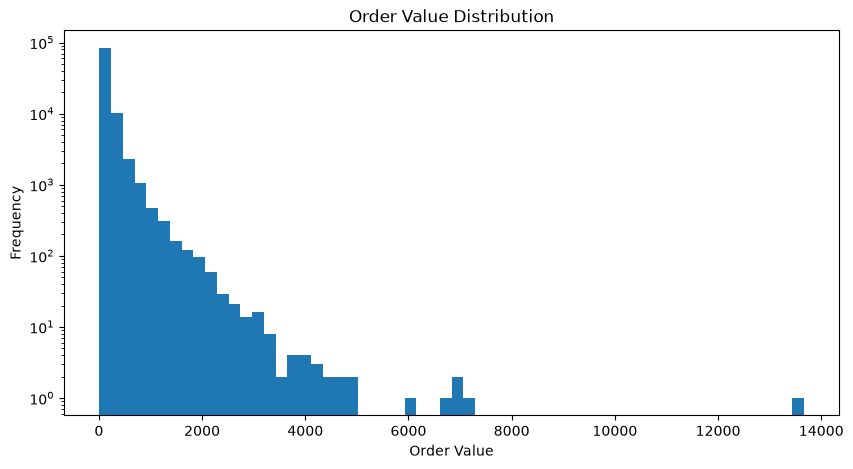

In [72]:
plt.figure(figsize=(10, 5))
(
gold_orders["order_value"]
# [ gold_orders["order_value"] <per_99 ]
.dropna()
.plot(kind="hist", bins=60 , log=True)
)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.show()


La distribution de la valeur des commandes est fortement asymétrique à droite. La majorité des commandes sont concentrées sur de faibles montants, tandis qu’un petit nombre de commandes présentent des valeurs très élevées. Cette longue traîne indique que la moyenne peut être influencée par quelques commandes exceptionnelles et qu’il est pertinent de compléter l’analyse avec la médiane et les quantiles. Ces valeurs extrêmes ne doivent pas être supprimées automatiquement, car elles peuvent correspondre à de véritables commandes de forte valeur.

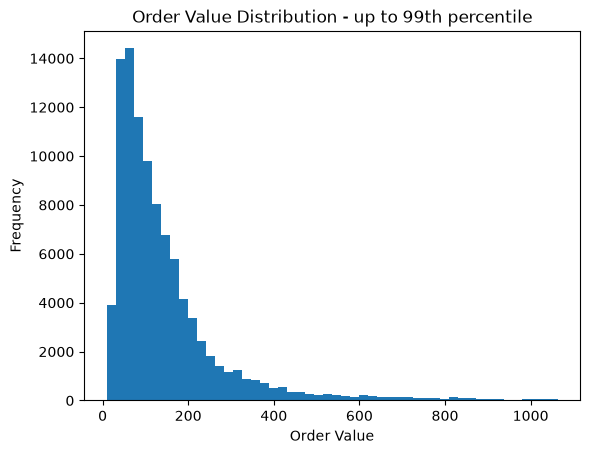

In [74]:
limit = gold_orders["order_value"].quantile(0.99)

gold_orders.loc[gold_orders["order_value"] <= limit, "order_value"].plot(
    kind="hist", bins=50
)

plt.title("Order Value Distribution - up to 99th percentile")
plt.xlabel("Order Value")
plt.show()


In [75]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

orders_by_day = gold_orders["purchase_day_name"].value_counts().reindex(day_order)

orders_by_day


purchase_day_name
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

In [ ]:
gold_orders["purchase_period"].value_counts().sort_index()

purchase_period
night         4740
morning      22240
afternoon    38361
evening      34100
Name: count, dtype: int64

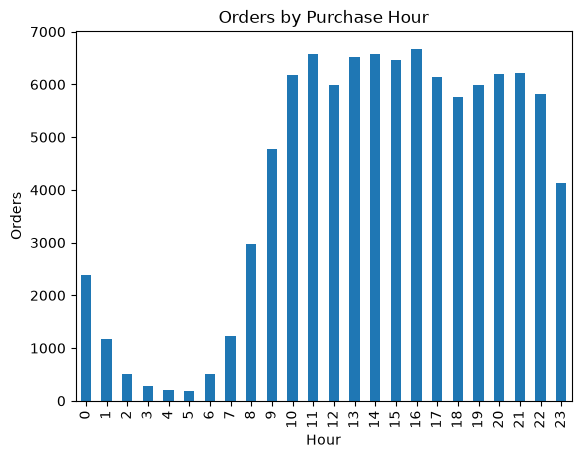

In [81]:
orders_by_hour = gold_orders.groupby("purchase_hour").size()

orders_by_hour.plot(kind="bar")

plt.title("Orders by Purchase Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()


In [118]:
gold_orders["purchase_period"].value_counts(normalize=True).sort_index() * 100


purchase_period
night        4.77
morning     22.37
afternoon   38.58
evening     34.29
Name: proportion, dtype: float64

La majorité des commandes sont passées pendant la journée et en soirée. L’après-midi représente la plus grande part de l’activité avec 38,58 % des commandes, suivi de la soirée avec 34,29 %. Le matin représente 22,37 %, tandis que la nuit reste marginale avec seulement 4,77 % des commandes. Au total, près de 73 % des commandes sont passées l’après-midi ou en soirée, ce qui indique que l’activité commerciale est principalement concentrée après midi et jusqu’en fin de journée.

In [82]:
gold_orders["freight_ratio"].describe()

count   98,666.00
mean         0.21
std          0.13
min          0.00
25%          0.12
50%          0.18
75%          0.28
max          0.96
Name: freight_ratio, dtype: float64

In [83]:
overall_freight_ratio = (
    gold_orders["freight_value"].sum() / gold_orders["order_value"].sum()
)

print(f"Freight share: {overall_freight_ratio:.2%}")


Freight share: 14.21%


In [84]:
avg_review_score = gold_orders["review_score"].mean()

positive_review_rate = gold_orders["is_positive_review"].mean() * 100

negative_review_rate = gold_orders["is_negative_review"].mean() * 100


In [85]:
print(f"Average review score : {avg_review_score:.2f}/5")
print(f"Positive reviews     : {positive_review_rate:.2f}%")
print(f"Negative reviews     : {negative_review_rate:.2f}%")


Average review score : 4.09/5
Positive reviews     : 77.05%
Negative reviews     : 14.64%


In [86]:
avg_delivery_days = gold_orders["delivery_days"].mean()

late_delivery_rate = gold_orders["is_late_delivery"].mean() * 100

very_late_rate = gold_orders["is_very_late_delivery"].mean() * 100


In [87]:
valid_logistics = gold_orders.loc[~gold_orders["dq_invalid_delivery_sequence"]]


In [88]:
avg_delivery_days = valid_logistics["delivery_days"].mean()
late_delivery_rate = valid_logistics["is_late_delivery"].mean() * 100


In [119]:
business_summary = pd.DataFrame(
    {
        "KPI": [
            "Total orders",
            "Unique customers",
            "Product revenue",
            "Gross order value",
            "Average order value",
            "Items sold",
            "Average items per order",
            "Repeat customer rate",
            "Average review score",
            "Late delivery rate",
        ],
        "Value": [
            gold_orders["order_id"].nunique(),
            gold_orders["customer_unique_id"].nunique(),
            gold_orders["products_value"].sum(),
            gold_orders["order_value"].sum(),
            gold_orders["order_value"].mean(),
            gold_orders["nb_items"].sum(),
            gold_orders["nb_items"].mean(),
            gold_customers["is_repeat_customer"].mean() * 100,
            gold_orders["review_score"].mean(),
            valid_logistics["is_late_delivery"].mean() * 100,
        ],
    }
)

business_summary


,KPI,Value
0,Total orders,"99,441.00"
1,Unique customers,"96,096.00"
2,Product revenue,"13,591,643.70"
3,Gross order value,"15,843,553.24"
4,Average order value,160.58
5,Items sold,"112,650.00"
6,Average items per order,1.14
7,Repeat customer rate,3.12
8,Average review score,4.09
9,Late delivery rate,6.78


L’activité comprend 99 441 commandes réalisées par 96 096 clients uniques, pour une valeur brute totale d’environ 15,84 millions. La valeur des produits représente environ 13,59 millions, la différence provenant principalement des frais de livraison. Le panier moyen est d’environ 160,58 pour 1,14 article par commande, indiquant que la majorité des commandes contiennent peu d’articles.

Le taux de clients récurrents est relativement faible, autour de 3 %, ce qui suggère que l’activité repose majoritairement sur des achats uniques. La satisfaction est néanmoins élevée, avec une note moyenne de 4,09/5. Environ 7 % des livraisons analysables arrivent après la date estimée, ce qui montre une performance logistique globalement correcte mais laisse une population de commandes à étudier plus précisément.